# 4장 실습 — 시간대별 통행시간과 경로 비교

3장에서는 도로마다 속도가 하나였고, 하남시청에서 미사역까지 5.54분이 나왔습니다.
그 속도는 막히지 않았을 때의 값입니다. 실제 속도는 시간대마다 다릅니다.
속도를 바꾸면 소요시간만 늘어나는 것이 아니라 **경로 자체가 달라집니다.** 교재 4장에 대응합니다.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "smartmob").is_dir())
sys.path[:0] = [str(ROOT), str(ROOT / "labs")]

from lab import banner, expect, todo
from smartmob.viz import use_korean_font

use_korean_font()

'Malgun Gothic'

## 1. 속도 컬럼이 여러 개입니다 (교재 4.1)

엣지 표에는 2장에서 지나친 컬럼들이 있습니다. 통계를 내기 전에 2장처럼 자동차 도로만 남깁니다.
`DRIVE_HIGHWAYS` 는 `load_road_graph(modes=("drive",))` 가 쓰는 것과 같은 도로 종류 집합입니다.
보도까지 섞인 표로 통계를 내면 자유류 중앙값이 15km/h 로 나와 교재와 다릅니다.

In [2]:
import pandas as pd

from smartmob.data import data_path
from smartmob.teaching.graph import DRIVE_HIGHWAYS

edges = pd.read_parquet(data_path("hanam/road_graph_edges.parquet"))
edges = edges[edges["highway"].isin(DRIVE_HIGHWAYS)]        # 자동차 도로만 남깁니다
print(f"자동차 도로 엣지 {len(edges):,}개")

speed_cols = [c for c in edges.columns if c.endswith("_p50") or c.endswith("speed_kmh")]
speed_cols

자동차 도로 엣지 28,589개


['free_flow_speed_kmh',
 'weekday_am_peak_p50',
 'weekday_am_shoulder_p50',
 'weekday_midday_p50',
 'weekday_afternoon_p50',
 'weekday_pm_peak_p50',
 'weekday_pm_shoulder_p50',
 'weekday_offpeak_p50',
 'weekday_night_p50']

`free_flow_speed_kmh` 는 막히지 않을 때의 속도이고, `weekday_*_p50` 여덟 개가 주중 시간대별 관측 속도입니다.
`p50` 은 중앙값이라는 뜻입니다. 시간대 구분은 이렇습니다.

| 슬롯 | 시간 | 슬롯 | 시간 |
|---|---|---|---|
| `offpeak` | 06–07 | `afternoon` | 12–17 |
| `am_peak` | 07–09 | `pm_peak` | 17–19 |
| `am_shoulder` | 09–10 | `pm_shoulder` | 19–22 |
| `midday` | 10–12 | `night` | 22–06 |

컬럼마다 중앙값과 결측 비율을 봅니다. `isna().mean()` 은 비어 있는 행의 비율입니다.

In [3]:
for c in speed_cols:
    print(f"{c:26s} 중앙값 {edges[c].median():5.1f} km/h   결측 {edges[c].isna().mean():5.1%}")

free_flow_speed_kmh        중앙값  30.0 km/h   결측  0.0%
weekday_am_peak_p50        중앙값  21.2 km/h   결측 21.7%
weekday_am_shoulder_p50    중앙값  20.5 km/h   결측 21.7%
weekday_midday_p50         중앙값  19.6 km/h   결측 21.7%
weekday_afternoon_p50      중앙값  19.6 km/h   결측 21.7%
weekday_pm_peak_p50        중앙값  18.9 km/h   결측 21.7%
weekday_pm_shoulder_p50    중앙값  19.8 km/h   결측 21.7%
weekday_offpeak_p50        중앙값  22.1 km/h   결측 21.7%
weekday_night_p50          중앙값  22.3 km/h   결측 21.7%


자유류 중앙값이 30km/h 인 도로의 실제 중앙값은 19~22km/h 입니다. 오후 첨두 `pm_peak` 가 18.9km/h 로 가장 느립니다.
관측 컬럼은 21.7%가 비어 있습니다. 관측 장비가 없거나 통행량이 적어 통계를 못 낸 도로입니다.
대부분 `residential` 과 `service` 이고, 간선도로는 거의 다 관측이 있습니다.
`load_road_graph` 는 이런 엣지를 자유류 속도로 채웁니다. 비워 두면 그 도로를 아예 못 쓰게 되므로 더 나쁩니다.

## 2. 시간과 속도 컬럼의 대응 (교재 4.1)

몇 시가 어느 컬럼을 쓰는지는 `HOUR_TO_COLUMN` 딕셔너리에 적혀 있습니다. 위 표를 코드로 옮긴 것입니다.

In [4]:
from smartmob.teaching.eta import HOUR_TO_COLUMN

for hour in [3, 8, 12, 18, 21]:
    print(f"{hour:2d}시 → {HOUR_TO_COLUMN[hour]}")

 3시 → weekday_night_p50
 8시 → weekday_am_peak_p50
12시 → weekday_afternoon_p50
18시 → weekday_pm_peak_p50
21시 → weekday_pm_shoulder_p50


3시는 `night`, 8시는 `am_peak`, 18시는 `pm_peak` 입니다.

## 3. 같은 구간, 다른 시간 (교재 4.2)

`load_road_graph` 에 `speed_column` 을 주면 그 컬럼으로 엣지 비용을 계산합니다.
`shortest_path` 는 교재 3.8절의 정리된 다익스트라입니다. 좌표를 받아 스냅부터 하고 `Path` 객체를 돌려줍니다.
`duration_s` 가 초, `nodes` 가 경로 노드 목록이고, `distance_km(g)` 가 경로 길이입니다.

먼저 자유류 기준값을 구하고, 시각 여덟 개를 골라 같은 구간을 다시 계산합니다.
시각마다 그래프를 새로 읽으므로 수십 초 걸립니다.

In [5]:
from smartmob.data import load_road_graph
from smartmob.teaching.dijkstra import shortest_path

HANAM_CITY_HALL = (37.5393, 127.2148)
MISA_STATION = (37.5606, 127.1930)

g_free = load_road_graph("hanam", modes=("drive",))           # speed_column 을 안 주면 자유류
p_free = shortest_path(g_free, HANAM_CITY_HALL, MISA_STATION, algorithm="dijkstra")
print(f"자유류  {p_free.duration_s / 60:.2f}분, {p_free.distance_km(g_free):.2f}km, 노드 {len(p_free.nodes)}개")

HOURS = [0, 6, 8, 11, 14, 17, 19, 22]
rows = []
for hour in HOURS:
    g = load_road_graph("hanam", modes=("drive",), speed_column=HOUR_TO_COLUMN[hour])
    p = shortest_path(g, HANAM_CITY_HALL, MISA_STATION, algorithm="dijkstra")
    rows.append({
        "hour": hour,
        "컬럼": HOUR_TO_COLUMN[hour],
        "소요_분": round(p.duration_s / 60, 2),
        "거리_km": round(p.distance_km(g), 2),
        "노드수": len(p.nodes),
    })

curve = pd.DataFrame(rows)     # 딕셔너리 목록을 표로 만듭니다. 행 하나가 시각 하나입니다
curve

자유류  5.54분, 4.16km, 노드 83개


,hour,컬럼,소요_분,거리_km,노드수
0,0,weekday_night_p50,7.96,4.45,76
1,6,weekday_offpeak_p50,8.17,4.45,76
2,8,weekday_am_peak_p50,8.14,4.45,76
3,11,weekday_midday_p50,8.94,4.08,77
4,14,weekday_afternoon_p50,8.94,4.08,77
5,17,weekday_pm_peak_p50,8.99,4.08,77
6,19,weekday_pm_shoulder_p50,8.58,4.08,77
7,22,weekday_night_p50,7.96,4.45,76


자유류로 5.54분이던 구간이 오후 첨두(17시)에는 8.99분, 즉 8분 59초입니다. 62% 더 걸립니다.
심야(0시, 22시)가 7.96분으로 가장 빠르지만 그래도 자유류보다 2분 넘게 깁니다.
`노드수` 열도 봅니다. 자유류 83개였던 경로가 76개 또는 77개로 바뀌었습니다.
다른 길로 간다는 뜻이고 5절에서 확인합니다.

## 4. 그림으로 봅니다 (교재 4.6)

시각을 가로축에, 소요시간을 세로축에 놓고 자유류 값을 붉은 점선으로 함께 그립니다.

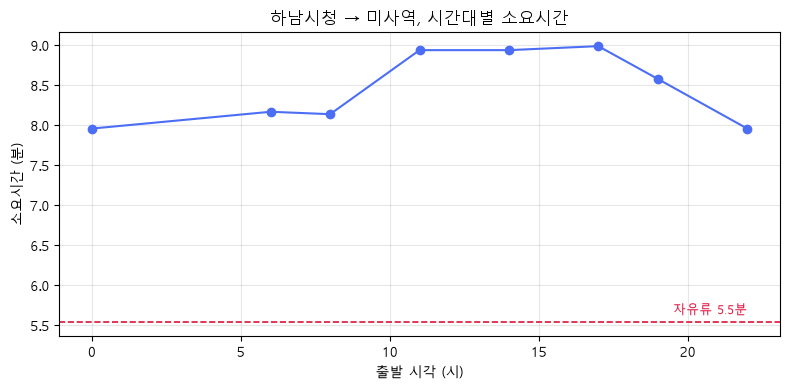

In [6]:
import matplotlib.pyplot as plt

free_min = p_free.duration_s / 60

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve["hour"], curve["소요_분"], marker="o", color="#4C6EF5")
ax.axhline(free_min, color="crimson", linestyle="--", linewidth=1.2)      # 가로 점선
ax.text(22, free_min + 0.1, f"자유류 {free_min:.1f}분", color="crimson", ha="right", fontsize=9)
ax.set_xlabel("출발 시각 (시)")
ax.set_ylabel("소요시간 (분)")
ax.set_title("하남시청 → 미사역, 시간대별 소요시간")
ax.grid(alpha=0.3)
plt.tight_layout();

자유류 선이 모든 시각보다 아래에 있습니다. 자유류 속도만 쓰는 시뮬레이션은 그만큼 낙관적인 결과를 냅니다.

## 5. 경로 자체가 달라집니다 (교재 4.3)

소요시간만 늘어나는 것이 아닙니다. 새벽 3시와 저녁 6시의 경로가 같은지 노드 목록을 직접 비교합니다.
`set(a) & set(b)` 는 두 경로에 모두 들어 있는 노드의 집합입니다.

In [7]:
g_night = load_road_graph("hanam", modes=("drive",), speed_column=HOUR_TO_COLUMN[3])
g_peak = load_road_graph("hanam", modes=("drive",), speed_column=HOUR_TO_COLUMN[18])

p_night = shortest_path(g_night, HANAM_CITY_HALL, MISA_STATION, algorithm="dijkstra")
p_peak = shortest_path(g_peak, HANAM_CITY_HALL, MISA_STATION, algorithm="dijkstra")

banner("새벽 3시 vs 저녁 6시")
print(f"새벽  {p_night.duration_s / 60:5.2f}분, 노드 {len(p_night.nodes)}개")
print(f"저녁  {p_peak.duration_s / 60:5.2f}분, 노드 {len(p_peak.nodes)}개")
print(f"경로가 같은가: {p_night.nodes == p_peak.nodes}")

shared = len(set(p_night.nodes) & set(p_peak.nodes))
print(f"겹치는 노드 {shared}개 / 새벽 경로 {len(p_night.nodes)}개")

새벽 3시 vs 저녁 6시
------------------------
새벽   7.96분, 노드 76개
저녁   8.99분, 노드 77개
경로가 같은가: False
겹치는 노드 66개 / 새벽 경로 76개


두 경로는 다릅니다. 새벽 경로 76개 노드 중 66개만 저녁 경로와 겹칩니다.

어느 길을 버리고 어느 길을 택했는지 도로 종류별 거리로 봅니다.
`neighbors` 가 돌려주는 엣지 번호로 엣지 표의 `highway` 와 `length` 를 찾고, `Counter` 로 종류별 km 를 더합니다.

In [8]:
from collections import Counter


def km_by_highway(g, p):
    km = Counter()                                    # 없는 키를 더하면 0에서 시작하는 딕셔너리
    for u, v in zip(p.nodes, p.nodes[1:]):            # 경로에서 이웃한 노드 쌍
        idx = next(i for nb, _, i in g.neighbors(u) if nb == v)   # 그 쌍을 잇는 엣지의 행 번호
        km[g.edges.loc[idx, "highway"]] += g.edges.loc[idx, "length"] / 1000
    return {h: round(float(d), 2) for h, d in km.most_common(3)}   # 많은 순으로 셋


banner("경로가 지나는 도로 종류 (km)")
for label, g, p in [("자유류", g_free, p_free), ("새벽 3시", g_night, p_night), ("저녁 6시", g_peak, p_peak)]:
    print(f"{label:6s} {km_by_highway(g, p)}")

경로가 지나는 도로 종류 (km)
------------------------
자유류    {'secondary': 3.13, 'tertiary': 0.55, 'primary': 0.25}
새벽 3시  {'primary': 1.89, 'tertiary': 1.08, 'secondary': 0.81}
저녁 6시  {'primary': 1.49, 'tertiary': 1.08, 'secondary': 0.81}


자유류 경로는 4.2km 중 3.1km 가 2차 간선(`secondary`)입니다.
실측 속도를 넣으면 그 길을 버리고 1차 간선(`primary`)과 3차 도로(`tertiary`)를 잇는 길로 갑니다.
큰길이 막혀 골목으로 가는 것이 아니라, 관측 속도가 낮게 잡힌 구간을 피해 다른 큰길로 가는 것입니다.
하나의 평균 속도로 시뮬레이션하면 이 차이가 통째로 사라집니다.

## 6. 지도에 두 경로를 겹쳐 봅니다

`coords(g)` 가 경로 노드의 (위도, 경도) 목록입니다.
그릴 때는 경도를 x, 위도를 y 에 놓아야 하므로 순서를 바꿉니다. `[::-1]` 이 튜플을 뒤집습니다.

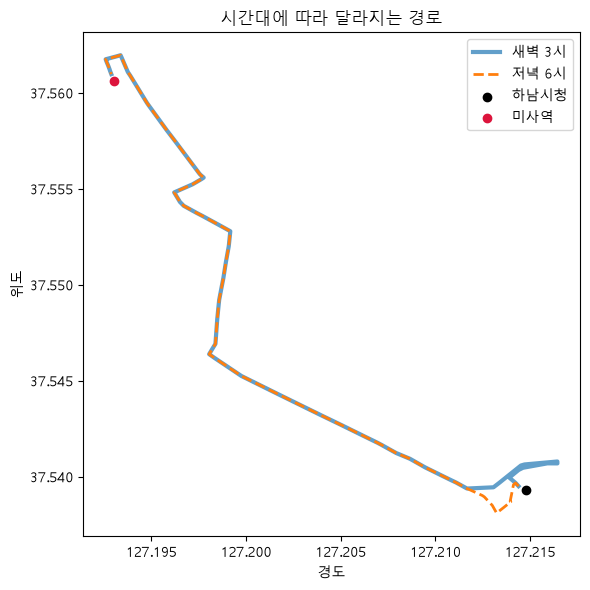

In [9]:
night_xy = p_night.coords(g_night)
peak_xy = p_peak.coords(g_peak)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([c[1] for c in night_xy], [c[0] for c in night_xy],      # c[1] 이 경도, c[0] 이 위도
        lw=3, alpha=0.7, label="새벽 3시")
ax.plot([c[1] for c in peak_xy], [c[0] for c in peak_xy],
        lw=2, ls="--", label="저녁 6시")
ax.scatter(*HANAM_CITY_HALL[::-1], c="black", zorder=5, label="하남시청")
ax.scatter(*MISA_STATION[::-1], c="crimson", zorder=5, label="미사역")
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.legend()
ax.set_title("시간대에 따라 달라지는 경로")
plt.tight_layout();

## 7. 빈칸

### 7.1 가장 느린 시간대

위 `curve` 표에서 소요시간이 가장 긴 시각과 가장 짧은 시각을 찾고, 그 비율을 구합니다.
`idxmax()` 와 `idxmin()` 으로 행을 찾고, 그 행의 `hour` 열을 읽습니다.

In [12]:
slowest_hour = curve.loc[curve["travel_time"].idxmax(), "hour"]     # 가장 오래 걸리는 출발 시각 (시)
fastest_hour = curve.loc[curve["travel_time"].idxmin(), "hour"]     # 가장 빨리 가는 출발 시각 (시)
ratio = curve["travel_time"].max() / curve["travel_time"].min()            # 느린 쪽 소요시간 ÷ 빠른 쪽 소요시간

banner("빈칸 7.1")
todo("가장 느린 시각", slowest_hour)
todo("가장 빠른 시각", fastest_hour)
todo("비율", ratio, fmt=lambda v: f"{v:.2f}배")

KeyError: 'travel_time'

### 7.2 다른 구간에서도 그런가

하남 안의 다른 두 지점을 골라 같은 곡선을 그려 봅니다.
좌표는 `g_free.coord` 에서 아무 노드나 두 개 골라도 되고, 지도에서 찾아 넣어도 됩니다.

시간대별 차이가 위 구간보다 큰지 작은지, 왜 그런지 두 줄로 적습니다.

In [11]:
my_origin = None        # (위도, 경도)
my_dest = None          # (위도, 경도)

if my_origin and my_dest:
    rows = []
    for hour in HOURS:
        g = load_road_graph("hanam", modes=("drive",), speed_column=HOUR_TO_COLUMN[hour])
        p = shortest_path(g, my_origin, my_dest, algorithm="dijkstra")
        rows.append({"hour": hour, "소요_분": round(p.duration_s / 60, 2)})
    display(pd.DataFrame(rows))
else:
    print("[ ] my_origin 과 my_dest 를 아직 채우지 않았습니다")

[ ] my_origin 과 my_dest 를 아직 채우지 않았습니다


## 정리

- 도로망 하나에 속도 컬럼이 여러 개 붙어 있고, `speed_column` 으로 골라 씁니다
- 자동차 도로의 자유류 중앙값은 30km/h, 관측 중앙값은 19~22km/h 이고 21.7%는 관측이 없습니다
- 하남시청→미사역은 자유류 5.54분, 오후 첨두 8.99분입니다. 경로도 2차 간선에서 1차 간선·3차 도로로 바뀝니다
- 시뮬레이션 한 번에 3만 회 넘게 질의하므로 파이썬 다익스트라로는 몇 분이 걸립니다 (교재 4.4)
- 실제 엔진은 축약 계층과 행렬 질의로 이를 감당하고, 우리는 HTTP로 부릅니다 (교재 4.5)
- 5장 실습에서는 대중교통 시간표 데이터로 넘어갑니다